## Import Library

In [ ]:
# Import Library
import pandas as pd
import re
import emoji
import numpy as np

# Import library untuk EDA
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

## Load Data

In [110]:
# Membaca Dataset
dataset1 = pd.read_csv('tokopedia-product-reviews-2019.csv')
dataset2 = pd.read_csv('tokopedia_product_reviews_2025.csv')

# Menampilkan Info
display(dataset1.info())
dataset2.info()

<class 'pandas.DataFrame'>
RangeIndex: 40607 entries, 0 to 40606
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    40607 non-null  int64
 1   text          40607 non-null  str  
 2   rating        40607 non-null  int64
 3   category      40607 non-null  str  
 4   product_name  40607 non-null  str  
 5   product_id    40607 non-null  int64
 6   sold          40593 non-null  str  
 7   shop_id       40607 non-null  int64
 8   product_url   40607 non-null  str  
dtypes: int64(4), str(5)
memory usage: 2.8 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   review_text       65543 non-null  str  
 1   review_date       65543 non-null  str  
 2   review_id         65543 non-null  int64
 3   product_name      65543 non-null  str  
 4   product_category  65543 non-null  str  
 5   product_variant   26749 non-null  str  
 6   product_price     65543 non-null  int64
 7   product_url       65543 non-null  str  
 8   product_id        65543 non-null  int64
 9   rating            65543 non-null  int64
 10  sold_count        65543 non-null  int64
 11  shop_id           65543 non-null  int64
 12  sentiment_label   65543 non-null  str  
dtypes: int64(6), str(7)
memory usage: 6.5 MB


In [111]:
# Menampilkan Dataset
display(dataset1.head())
display(dataset2.head())

,Unnamed: 0,text,rating,category,product_name,product_id,sold,shop_id,product_url
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - S...,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staple...
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; O...,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-stap...
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gu...,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-ref...


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


In [112]:
# Mengambil Kolom Ulasan dan Rating
dataset1 = dataset1[['text', 'rating']]
dataset2 = dataset2[['review_text', 'rating']]

# Mengubah Nama Kolom
dataset1.columns = ['ulasan', 'rating']
dataset2.columns = ['ulasan', 'rating']

# Menggabungkan Dataset
dataset = pd.concat([dataset1, dataset2], ignore_index=True)

## Preprocessing

In [113]:
# Menampilkan Dataset
display(dataset.head())

# Menampilkan Info
dataset.info()

,ulasan,rating
0,Barang sesuai pesanan dan cepat sampai,5
1,Barang bagus harga murah,5
2,Paket rapi...mantap....cepat....sampe ke tujuan,5
3,ya saya puas dgn barangnya,5
4,Responya luar biasa b mantap,5


<class 'pandas.DataFrame'>
RangeIndex: 106150 entries, 0 to 106149
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   ulasan  106150 non-null  str  
 1   rating  106150 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.6 MB


In [114]:
# Melihat Informasi Statistik Ulasan
display(pd.DataFrame(dataset['ulasan'].str.len().describe().round(0)))
dataset.describe().round(0)

,ulasan
count,106150.0
mean,70.0
std,140.0
min,4.0
25%,33.0
50%,51.0
75%,83.0
max,32857.0


,rating
count,106150.0
mean,5.0
std,1.0
min,1.0
25%,5.0
50%,5.0
75%,5.0
max,5.0


In [115]:
# Mengecek Isi Dataset
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Null     : \n{dataset.isna().sum()}')
print(f"Jumlah Data Kosong : {(dataset['ulasan'].str.strip() == ' ').sum()}")

# Menampilkan Isi Yang Jumlah Karakternya Max
display(dataset[dataset['ulasan'].str.len() == dataset['ulasan'].str.len().max()])
dataset.loc[87139, 'ulasan']

Jumlah Duplikat : 10607
Jumlah Null     : 
ulasan    0
rating    0
dtype: int64
Jumlah Data Kosong : 0


,ulasan,rating
87139,TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE...,5


'TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS THE BEST. . . .TOP MANTAP IS

In [116]:
# Menghapus Data Duplikat
dataset = dataset.drop_duplicates()
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Dataset  : {len(dataset)}')

# Menghapus Kata Yang Panjang dan Berulang
dataset.drop(index=[105534, 87139], inplace=True)

Jumlah Duplikat : 0
Jumlah Dataset  : 95543


In [117]:
# Melihat Ulasan Yang Hanya Berisi Simbol
simbol = dataset['ulasan'].apply(lambda x: len(str(x).strip('.!? ')) == 0)

print("Jumlah simbol saja:", simbol.sum())

df_simbol = dataset[simbol][['ulasan']]
df_simbol

Jumlah simbol saja: 75


,ulasan
586,......................
1351,..................................
1682,!!!!!!!!!!!!!!!!!!!!!!!!!!!!
1924,.................................................
2818,......................
...,...
39420,...............................
40075,.....................
40580,...............................................
83245,......................................


In [118]:
# Fungsi Preprocessing Teks
def preprocessing_teks(teks) : 
    # Formatting Teks
    teks = teks.lower()

    # Hapus URL
    teks = re.sub(r'https?://\S+|www\.\S+', '', teks)
    teks = re.sub(r'\b\S+\.(com|co\.id|id|net|org|io|app|xyz)(\S*)', '', teks)

    # Menghapus Hastag dan Mention
    teks = re.sub(r'[@#]\S+', '', teks)

    # Menghapus Karakter Berulang
    teks = re.sub(r'(.)\1{2,}', r'\1', str(teks))

    # Merubah Icon Emoji Menjadi Teks
    teks = emoji.demojize(teks, delimiters=(" ", " "))
    teks = teks.replace("_", " ")

    # Mengubah semua tanda baca dan simbol selain huruf/angka menjadi spasi
    teks = re.sub(r'[^\w\s]', ' ', teks)

    # Menghapus Spasi Berlebih
    teks = re.sub(r'\s+', ' ', teks).strip()

    # Mengatasi Ulasan Yang Cuman Simbol
    if len(teks) == 0:
        return ""

    return teks

In [119]:
# Membaca Dataset Kata Slang
data_slang = pd.read_csv('slang.csv')
data_slang = data_slang[['slang', 'formal']]

# Ubah Menjadi Dictionary
dict_slang = dict(
    zip(data_slang['slang'], data_slang['formal'])
)

# Fungsi Normalisasi Kata
def normalisasi_kata(teks):
    kata = teks.split()

    normalisasi = [
        dict_slang.get(word, word)
        for word in kata
    ]

    return " ".join(normalisasi)

In [120]:
# Menerapkan Fungsi Ke Dataset
dataset['ulasan'] = (
    dataset['ulasan']
    .apply(preprocessing_teks)
    .apply(normalisasi_kata)
)

## Cek Hasil Preprocessing

In [121]:
# Fungsi Validasi Hasil Processing
def cek_hasil_preprocessing(dataset, kolom='ulasan'):

    print("=" * 30)
    print("HASIL VALIDASI PREPROCESSING")
    print("=" * 30)

    hasil = {
        "URL":
            dataset[kolom].str.contains(
                r'https?://|www\.',
                regex=True,
                na=False
            ).sum(),

        "Mention/Hashtag":
            dataset[kolom].str.contains(
                r'@\w+|#\w+',
                regex=True,
                na=False
            ).sum(),

        "Emoji":
            dataset[kolom].apply(
                lambda x: len(emoji.emoji_list(str(x))) > 0
            ).sum(),

        "Karakter Berulang":
            dataset[kolom].apply(
                lambda x: bool(re.search(r'(.)\1{2,}', str(x)))
            ).sum(),

        "Karakter Aneh":
            dataset[kolom].str.contains(
                r'[^\w\s.,?!-]',
                regex=True,
                na=False
            ).sum(),

        "Spasi Berlebih":
            dataset[kolom].str.contains(
                r'\s{2,}',
                regex=True,
                na=False
            ).sum(),

        "Review Kosong":
            (
                dataset[kolom]
                .fillna('')
                .str.strip() == ''
            ).sum()
    }

    for item, jumlah in hasil.items():
        print(f"{item:<20} : {jumlah}")

    print(f'\nJumlah Dataset       : {len(dataset)}')

In [122]:
cek_hasil_preprocessing(dataset)

HASIL VALIDASI PREPROCESSING
URL                  : 0
Mention/Hashtag      : 0
Emoji                : 0
Karakter Berulang    : 0
Karakter Aneh        : 0
Spasi Berlebih       : 0
Review Kosong        : 107

Jumlah Dataset       : 95541


In [123]:
# Hapus review kosong
dataset = dataset[
    dataset['ulasan'].str.strip() != ''
]

# Rapikan index
dataset.reset_index(drop=True, inplace=True)

# Cek Hasil
cek_hasil_preprocessing(dataset)

HASIL VALIDASI PREPROCESSING
URL                  : 0
Mention/Hashtag      : 0
Emoji                : 0
Karakter Berulang    : 0
Karakter Aneh        : 0
Spasi Berlebih       : 0
Review Kosong        : 0

Jumlah Dataset       : 95434


In [124]:
# Menampilkan Dataset
dataset.head(10)

,ulasan,rating
0,barang sesuai pesanan dan cepat sampai,5
1,barang bagus harga murah,5
2,paket rapi mantap cepat sampai ke tujuan,5
3,ya saya puas dengan barangnya,5
4,responya luar biasa b mantap,5
5,seller top pengiriman cepat barang oke,5
6,pengiriman cepat seller top,5
7,produk sesuai dengan spec di web dan respon se...,5
8,respon super cepat pengiriman cepat barang bag...,5
9,barang mantap pelayanan cepat,5


## Labeling

In [125]:
# Load Kamus
lexicon_positive = pd.read_csv(
    'lexicon_positive.tsv',
    sep='\t',
    header=0
)

lexicon_positive.columns = [
    'word',
    'weight'
]

lexicon_positive.head(10)

,word,weight
0,hai,3
1,merekam,2
2,ekstensif,3
3,paripurna,1
4,detail,2
5,pernik,3
6,belas,2
7,welas,4
8,kabung,1
9,rahayu,4


In [126]:
lexicon_negative = pd.read_csv(
    'lexicon_negative.tsv',
    sep='\t',
    header=0
)

lexicon_negative.columns = [
    'word',
    'weight'
]

lexicon_negative.head(10)

,word,weight
0,putus tali gantung,-2
1,gelebah,-2
2,gobar hati,-2
3,tersentuh (perasaan),-1
4,isak,-5
5,larat hati,-3
6,nelangsa,-3
7,remuk redam,-5
8,tidak segan,-2
9,gemar,-1


In [127]:
# Membuat Dictionary Positif
positive_dict = {}
for index, row in lexicon_positive.iterrows():
    positive_dict[row['word']] = int(row['weight']) 

In [128]:
# Membuat Dictionary Negatif
negative_dict = {}
for index, row in lexicon_negative.iterrows():
    negative_dict[row['word']] = int(row['weight'])

In [129]:
# Membuat Fungsi Scoring
def sentiment_score(text):

    words = text.split()

    score = 0

    for word in words:

        if word in positive_dict:
            score += positive_dict[word]

        elif word in negative_dict:
            score += negative_dict[word]

    return score

In [130]:
dataset.columns

Index(['ulasan', 'rating'], dtype='str')

In [131]:
# 1. Menambahkan istilah khusus  ke kamus positif
kata_ecommerce_positif = {
    'aman': 4,
    'packing': 3,
    'deskripsi': 2,
    'fast': 3,
    'thumbs': 3, 
    'ori': 4,
    'original': 4,
    'berfungsi': 3,
    'normal': 2,
    'lancar': 3
}

# Update dictionary positif
positive_dict.update(kata_ecommerce_positif)


# 2. Daftar kata yang salah masuk di kamus negatif 
kata_salah_negatif = [
    'cepat', 'bagus', 'sudah', 'pengiriman', 'yang', 
    'kasih', 'sampai', 'baik', 'rapi', 'deskripsi', 
    'sangat', 'saya', 'ada', 'enak'
]

# Hapus kata-kata tersebut dari kamus negatif 
for kata in kata_salah_negatif:
    if kata in negative_dict:
        del negative_dict[kata]
        
print("Kamus berhasil di-update dan dibersihkan!")

Kamus berhasil di-update dan dibersihkan!


In [132]:
dataset['clean_text'] = dataset['ulasan'].apply(
    preprocessing_teks
)

dataset[['ulasan','clean_text']].head()

,ulasan,clean_text
0,barang sesuai pesanan dan cepat sampai,barang sesuai pesanan dan cepat sampai
1,barang bagus harga murah,barang bagus harga murah
2,paket rapi mantap cepat sampai ke tujuan,paket rapi mantap cepat sampai ke tujuan
3,ya saya puas dengan barangnya,ya saya puas dengan barangnya
4,responya luar biasa b mantap,responya luar biasa b mantap


In [138]:
# Hitung Scor
dataset['score_sentimen'] = dataset['clean_text'].apply(
    sentiment_score
)
dataset[['clean_text','score_sentimen']].head(25)

,clean_text,score_sentimen
0,barang sesuai pesanan dan cepat sampai,8
1,barang bagus harga murah,8
2,paket rapi mantap cepat sampai ke tujuan,17
3,ya saya puas dengan barangnya,7
4,responya luar biasa b mantap,7
5,seller top pengiriman cepat barang oke,10
6,pengiriman cepat seller top,8
7,produk sesuai dengan spec di web dan respon se...,14
8,respon super cepat pengiriman cepat barang bag...,18
9,barang mantap pelayanan cepat,11


In [134]:
# Membuat Label Sentimen
def labeling(score):

    if score > 0:
        return 'Positif'

    elif score < 0:
        return 'Negatif'

    else:
        return 'Netral'

In [135]:
dataset['label'] = dataset['score_sentimen'].apply(
    labeling
)

In [137]:
# Cek Hasil Labeling
dataset[
    ['clean_text',
     'score_sentimen',
     'label']
].head(25)

,clean_text,score_sentimen,label
0,barang sesuai pesanan dan cepat sampai,8,Positif
1,barang bagus harga murah,8,Positif
2,paket rapi mantap cepat sampai ke tujuan,17,Positif
3,ya saya puas dengan barangnya,7,Positif
4,responya luar biasa b mantap,7,Positif
5,seller top pengiriman cepat barang oke,10,Positif
6,pengiriman cepat seller top,8,Positif
7,produk sesuai dengan spec di web dan respon se...,14,Positif
8,respon super cepat pengiriman cepat barang bag...,18,Positif
9,barang mantap pelayanan cepat,11,Positif


## Exploratory Data Analysis

In [139]:
# Distribusi Label
dataset['label'].value_counts()

label
Positif    85880
Negatif     6022
Netral      3532
Name: count, dtype: int64

In [140]:
# Cek Missing Value
dataset.isnull().sum()

ulasan            0
rating            0
clean_text        0
score_sentimen    0
label             0
dtype: int64

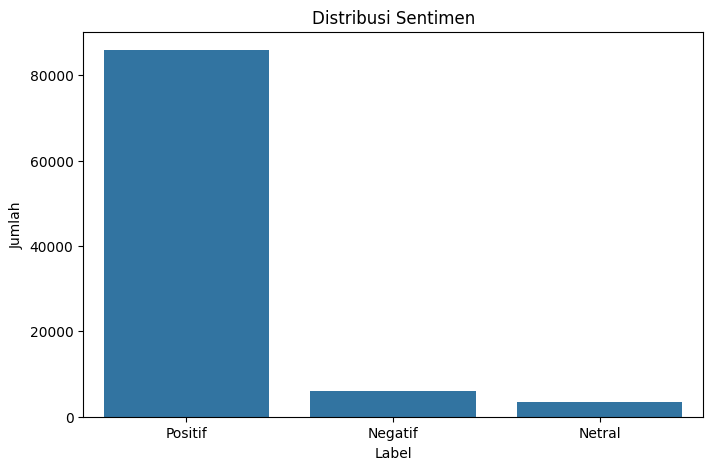

In [147]:
# Visualisasi Distribusi Sentimen

plt.figure(figsize=(8,5))

sns.countplot(
    x='label',
    data=dataset
)

plt.title('Distribusi Sentimen')
plt.xlabel('Label')
plt.ylabel('Jumlah')

plt.show()

In [142]:
# EDA Panjang Ulasan
dataset['jumlah_kata'] = (
    dataset['clean_text']
    .apply(lambda x: len(str(x).split()))
)

In [143]:
dataset['jumlah_kata'].describe()

count    95434.000000
mean        11.350074
std         12.008318
min          1.000000
25%          5.000000
50%          8.000000
75%         14.000000
max       1022.000000
Name: jumlah_kata, dtype: float64

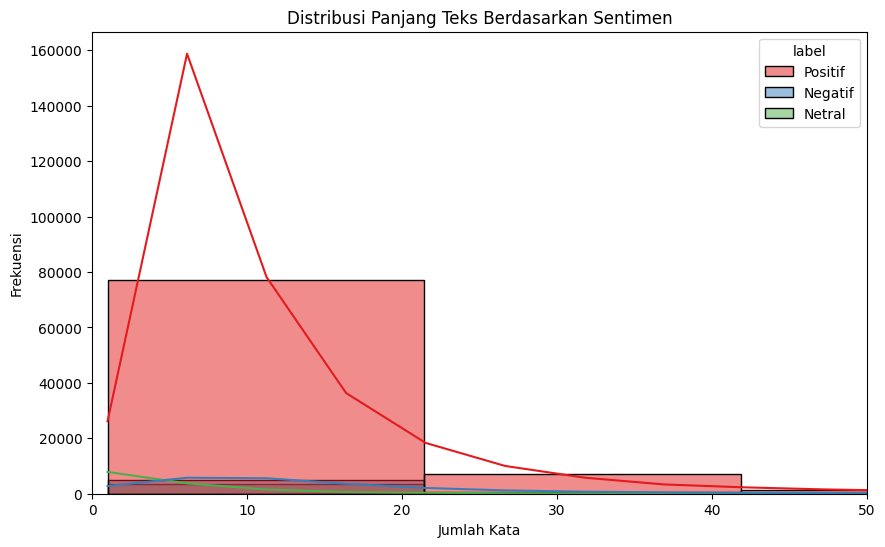

In [ ]:
# Tambahkan kolom jumlah kata
dataset['jumlah_kata'] = dataset['clean_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=dataset, x='jumlah_kata', hue='label', kde=True, bins=50, palette='Set1')
plt.title('Distribusi Panjang Teks Berdasarkan Sentimen')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 50) 
plt.show()

In [148]:
# World Cloud Positif
text_positif = " ".join(
    dataset[
        dataset['label']=='Positif'
    ]['clean_text']
)

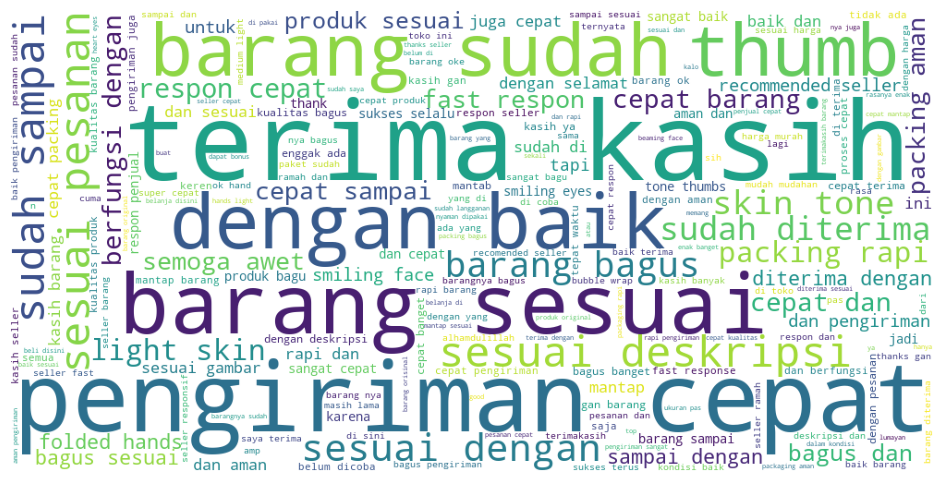

In [149]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_positif)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [150]:
# World Cloud Negatif
text_negatif = " ".join(
    dataset[
        dataset['label']=='Negatif'
    ]['clean_text']
)

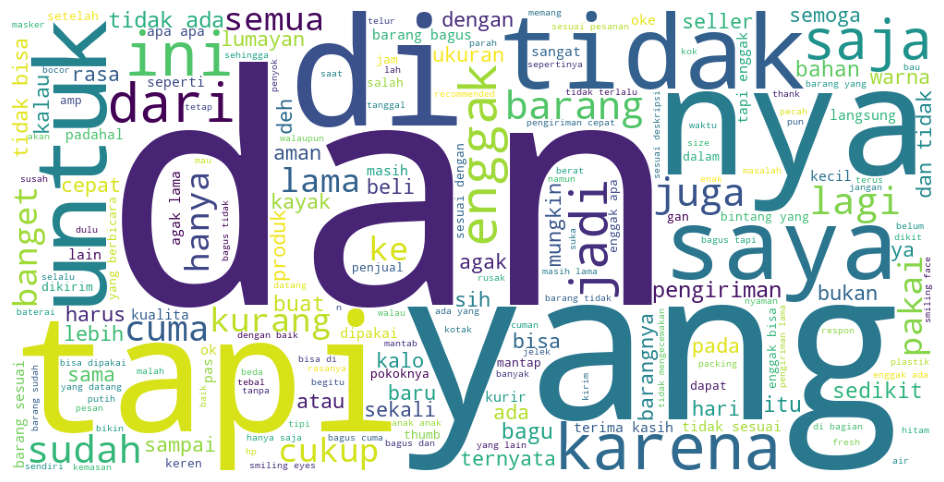

In [151]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_negatif)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [152]:
# Wourld Cloud Netral
text_netral = " ".join(
    dataset[
        dataset['label'] == 'Netral'
    ]['clean_text']
)

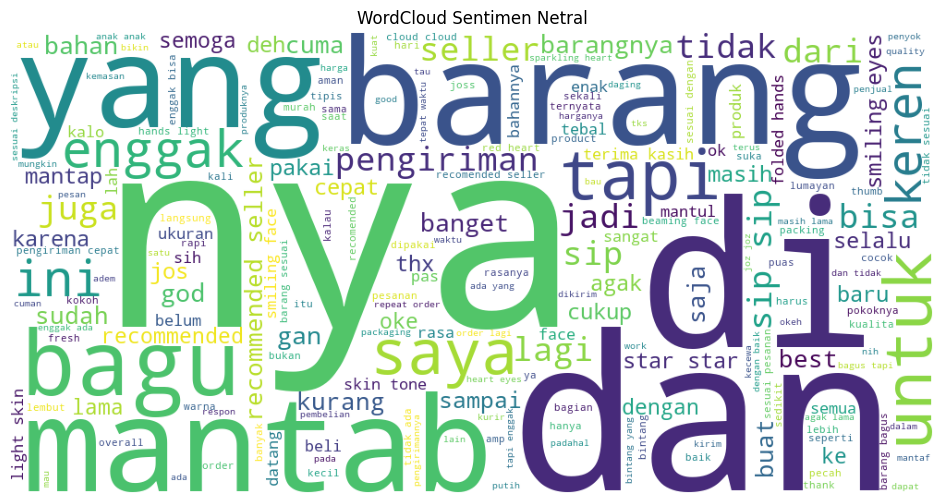

In [153]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_netral)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('WordCloud Sentimen Netral')

plt.show()

C:\Users\RANURA\AppData\Local\Temp\ipykernel_24280\1327690244.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')


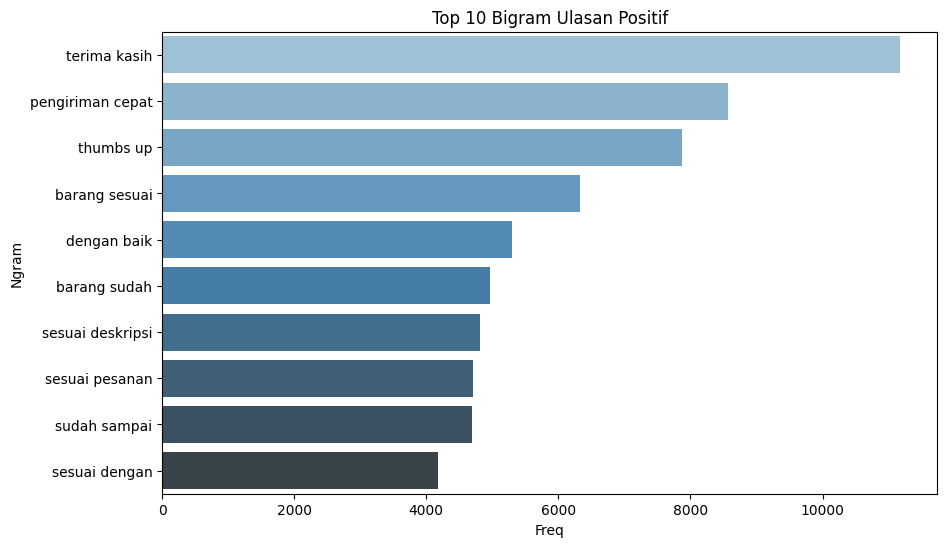

In [ ]:
# Analisis Bigram
def plot_top_ngrams(corpus, n=None, ngram_range=(2,2), title="Top 10 Bigrams"):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    top_df = pd.DataFrame(words_freq[:n], columns=['Ngram', 'Freq'])
    
    plt.figure(figsize=(10,6))
    sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')
    plt.title(title)
    plt.show()

# Panggil fungsi untuk Bigram Positif
plot_top_ngrams(dataset[dataset['label'] == 'Positif']['clean_text'], n=10, ngram_range=(2,2), title='Top 10 Bigram Ulasan Positif')

C:\Users\RANURA\AppData\Local\Temp\ipykernel_24280\2113471447.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')


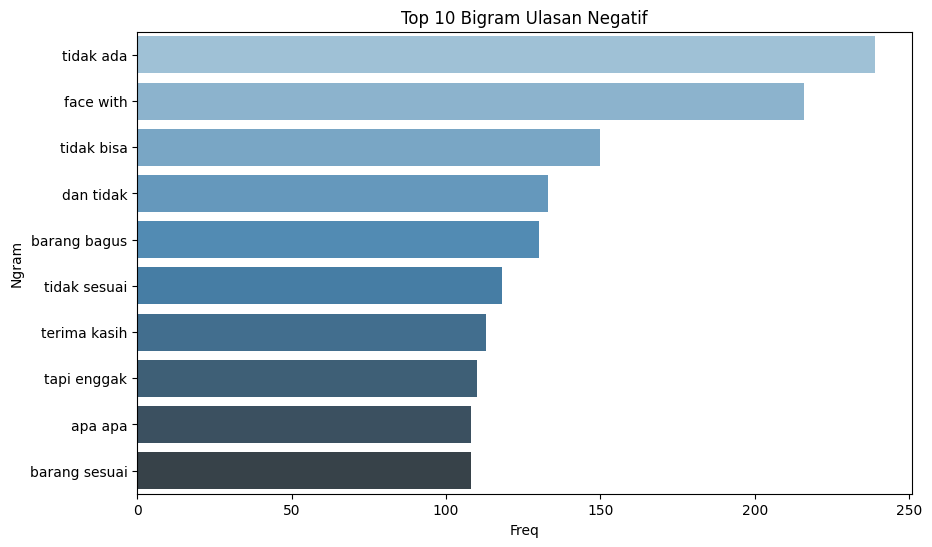

In [ ]:
# Analisis Bigram
def plot_top_ngrams(corpus, n=None, ngram_range=(2,2), title="Top 10 Bigrams"):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    top_df = pd.DataFrame(words_freq[:n], columns=['Ngram', 'Freq'])
    
    plt.figure(figsize=(10,6))
    sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')
    plt.title(title)
    plt.show()

# Panggil fungsi untuk Bigram Negatif
plot_top_ngrams(dataset[dataset['label'] == 'Negatif']['clean_text'], n=10, ngram_range=(2,2), title='Top 10 Bigram Ulasan Negatif')

In [ ]:
# Top 20 Kata Positif
kata_pos = " ".join(
    dataset[
        dataset['label']=='Positif'
    ]['clean_text']
).split()

counter_pos = Counter(kata_pos)

top20_pos = counter_pos.most_common(20)

pd.DataFrame(
    top20_pos,
    columns=['Kata','Frekuensi']
)

,Kata,Frekuensi
0,barang,27205
1,dan,27083
2,cepat,25993
3,sesuai,24180
4,bagus,20005
5,dengan,15843
6,sudah,15664
7,pengiriman,14137
8,terima,13062
9,kasih,11961


In [ ]:
# Top 20 Kata Negatif
kata_neg = " ".join(
    dataset[
        dataset['label']=='Negatif'
    ]['clean_text']
).split()

counter_neg = Counter(kata_neg)

top20_neg = counter_neg.most_common(20)

pd.DataFrame(
    top20_neg,
    columns=['Kata','Frekuensi']
)

,Kata,Frekuensi
0,tidak,1876
1,yang,1817
2,di,1463
3,dan,1425
4,enggak,1196
5,tapi,1178
6,bagus,1107
7,barang,1092
8,nya,1020
9,saya,907


In [156]:
pd.crosstab(
    dataset['rating'],
    dataset['label']
)

label,Negatif,Netral,Positif
rating,,,
1,456,75,544
2,261,50,318
3,636,195,1737
4,1054,407,7991
5,3615,2805,75290


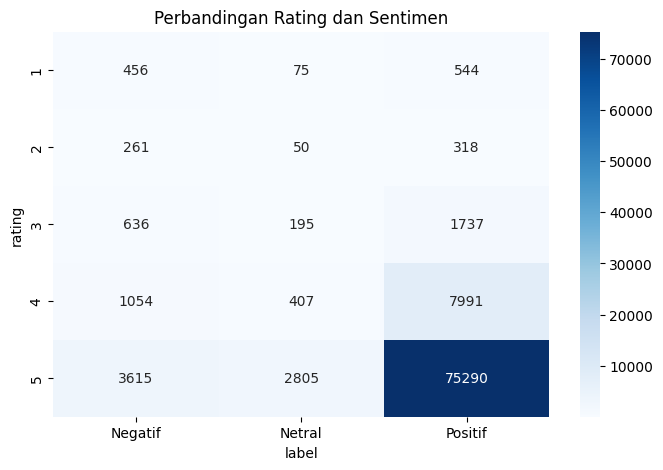

In [157]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pd.crosstab(
        dataset['rating'],
        dataset['label']
    ),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Perbandingan Rating dan Sentimen'
)

plt.show()

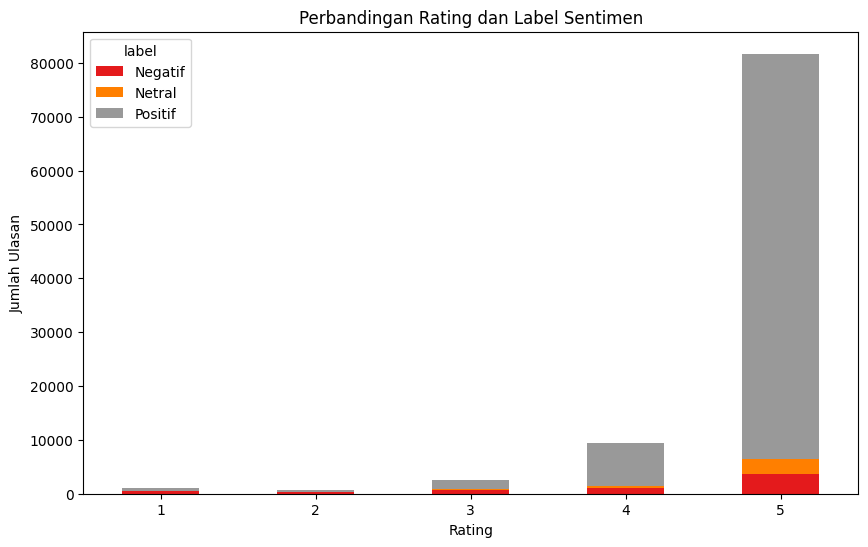

In [164]:
crosstab_data = pd.crosstab(dataset['rating'], dataset['label'])
crosstab_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set1')
plt.title('Perbandingan Rating dan Label Sentimen')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=0)
plt.show()